# Reactivities vs Temperature

Plot all reactivity channels available in `src/physics/reactivity_functions.py`
over a configurable ion-temperature range (keV).


In [7]:
from pathlib import Path
import sys

# Add repository root so `src` can be imported when running from `examples/`.
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_repo_root = next((p for p in _candidates if (p / 'src').is_dir()), None)
if _repo_root is None:
    raise RuntimeError("Could not locate repository root containing 'src/'")
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 16
LABEL_FONTSIZE = 16
TITLE_FONTSIZE = 18
LEGEND_FONTSIZE = 16

plt.rcParams.update({
    'font.size': BASE_FONTSIZE,
    'axes.titlesize': TITLE_FONTSIZE,
    'axes.labelsize': LABEL_FONTSIZE,
    'xtick.labelsize': BASE_FONTSIZE,
    'ytick.labelsize': BASE_FONTSIZE,
    'legend.fontsize': LEGEND_FONTSIZE,
})

from src.physics.reactivity_functions import (
    sigmav_DT_BoschHale,
    sigmav_DD_BoschHale,
    sigmav_DHe3_BoschHale,
    sigmav_TT_CF88,
    sigmav_He3He3_CF88,
    sigmav_THe3_CF88,
)

# Plot style definitions (single color per reaction family)
REACTION_COLORS = {
    'DT': 'tab:purple',
    'DD': 'tab:blue',
    'DHe3': 'tab:cyan',
    'TT': 'tab:red',
    'He3He3': 'tab:green',
    'THe3': 'tab:orange',
}

# Explicit per-channel plotting style (unique linestyle defined here)
CHANNEL_STYLE = {
    'DT': {'color': REACTION_COLORS['DT'], 'linestyle': '-', 'label': 'DT'},
    'DD_total': {'color': REACTION_COLORS['DD'], 'linestyle': '-', 'label': 'DD total'},
    'DD_n': {'color': REACTION_COLORS['DD'], 'linestyle': '--', 'label': 'DDn'},
    'DD_p': {'color': REACTION_COLORS['DD'], 'linestyle': ':', 'label': 'DDp'},
    'DHe3': {'color': REACTION_COLORS['DHe3'], 'linestyle': '-', 'label': 'DHe3'},
    'TT': {'color': REACTION_COLORS['TT'], 'linestyle': '-', 'label': 'TT'},
    'He3He3': {'color': REACTION_COLORS['He3He3'], 'linestyle': '-', 'label': 'He3He3'},
    'THe3_total': {'color': REACTION_COLORS['THe3'], 'linestyle': '-', 'label': 'THe3 total'},
    'THe3_ch1': {'color': REACTION_COLORS['THe3'], 'linestyle': '-.', 'label': 'THe3 ch1'},
    'THe3_ch2': {'color': REACTION_COLORS['THe3'], 'linestyle': '--', 'label': 'THe3 ch2'},
    'THe3_ch3': {'color': REACTION_COLORS['THe3'], 'linestyle': ':', 'label': 'THe3 ch3'},
}



In [8]:
# Temperature range (keV)
T_min_keV = 0.5
T_max_keV = 300.0
n_points = 1000

if T_min_keV <= 0 or T_max_keV <= T_min_keV:
    raise ValueError('Use 0 < T_min_keV < T_max_keV')

T_keV = np.geomspace(T_min_keV, T_max_keV, n_points)
print(f'Temperature range: {T_min_keV:g} -> {T_max_keV:g} keV, points={n_points}')


Temperature range: 0.5 -> 300 keV, points=1000


In [9]:
# Compute all channels from reactivity_functions.py
sigmav_DT = np.asarray(sigmav_DT_BoschHale(T_keV), dtype=float)
sigmav_DD_tot, sigmav_DD_n, sigmav_DD_p = sigmav_DD_BoschHale(T_keV)
sigmav_DD_tot = np.asarray(sigmav_DD_tot, dtype=float)
sigmav_DD_n = np.asarray(sigmav_DD_n, dtype=float)
sigmav_DD_p = np.asarray(sigmav_DD_p, dtype=float)
sigmav_DHe3 = np.asarray(sigmav_DHe3_BoschHale(T_keV), dtype=float)
sigmav_TT = np.asarray(sigmav_TT_CF88(T_keV), dtype=float)
sigmav_He3He3 = np.asarray(sigmav_He3He3_CF88(T_keV), dtype=float)
sigmav_THe3_ch1, sigmav_THe3_ch2, sigmav_THe3_ch3 = sigmav_THe3_CF88(T_keV)
sigmav_THe3_ch1 = np.asarray(sigmav_THe3_ch1, dtype=float)
sigmav_THe3_ch2 = np.asarray(sigmav_THe3_ch2, dtype=float)
sigmav_THe3_ch3 = np.asarray(sigmav_THe3_ch3, dtype=float)
sigmav_THe3_total = sigmav_THe3_ch1 + sigmav_THe3_ch2 + sigmav_THe3_ch3

reactivities = {
    'DT': sigmav_DT,
    'DD_total': sigmav_DD_tot,
    'DD_n': sigmav_DD_n,
    'DD_p': sigmav_DD_p,
    'DHe3': sigmav_DHe3,
    'TT': sigmav_TT,
    'He3He3': sigmav_He3He3,
    'THe3_total': sigmav_THe3_total,
    'THe3_ch1': sigmav_THe3_ch1,
    'THe3_ch2': sigmav_THe3_ch2,
    'THe3_ch3': sigmav_THe3_ch3,
}

print('Computed channels:')
for name, values in reactivities.items():
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        print(f'  {name:10s}: no finite values')
    else:
        print(f'  {name:10s}: min={finite.min():.3e}  max={finite.max():.3e}  [m^3/s]')



Computed channels:
  DT        : min=5.697e-29  max=8.942e-22  [m^3/s]
  DD_total  : min=2.373e-30  max=1.254e-22  [m^3/s]
  DD_n      : min=1.204e-30  max=4.702e-23  [m^3/s]
  DD_p      : min=1.169e-30  max=7.842e-23  [m^3/s]
  DHe3      : min=1.241e-35  max=3.435e-22  [m^3/s]
  TT        : min=1.441e-31  max=8.334e-23  [m^3/s]
  He3He3    : min=6.576e-48  max=3.959e-23  [m^3/s]
  THe3_total: min=0.000e+00  max=3.047e-22  [m^3/s]
  THe3_ch1  : min=0.000e+00  max=1.877e-22  [m^3/s]
  THe3_ch2  : min=0.000e+00  max=1.170e-22  [m^3/s]
  THe3_ch3  : min=0.000e+00  max=0.000e+00  [m^3/s]


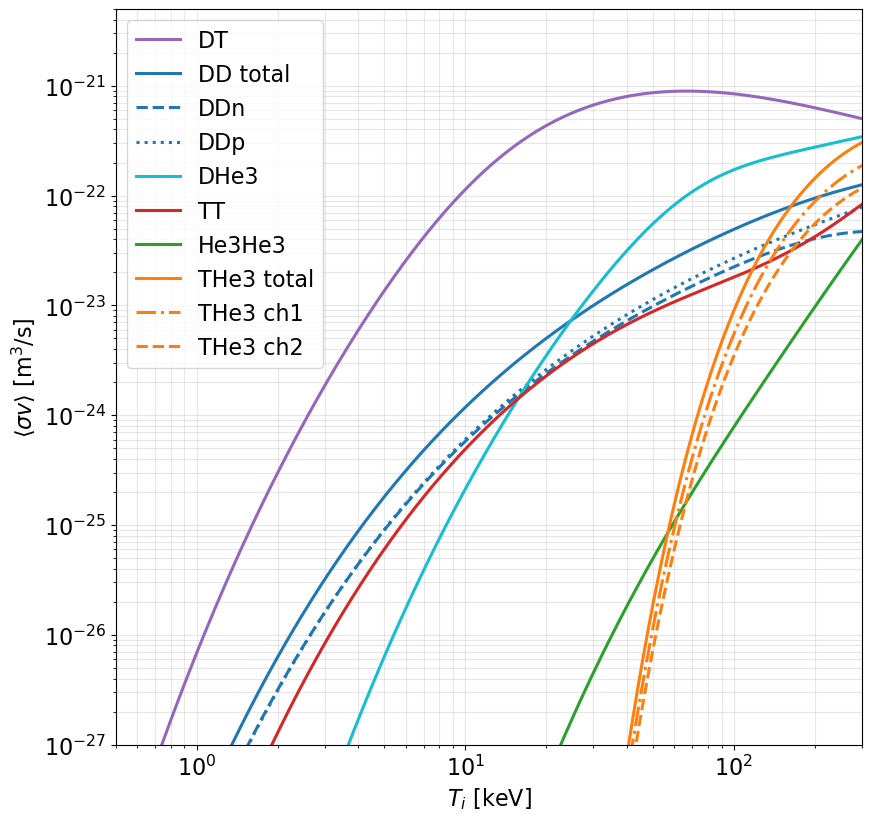

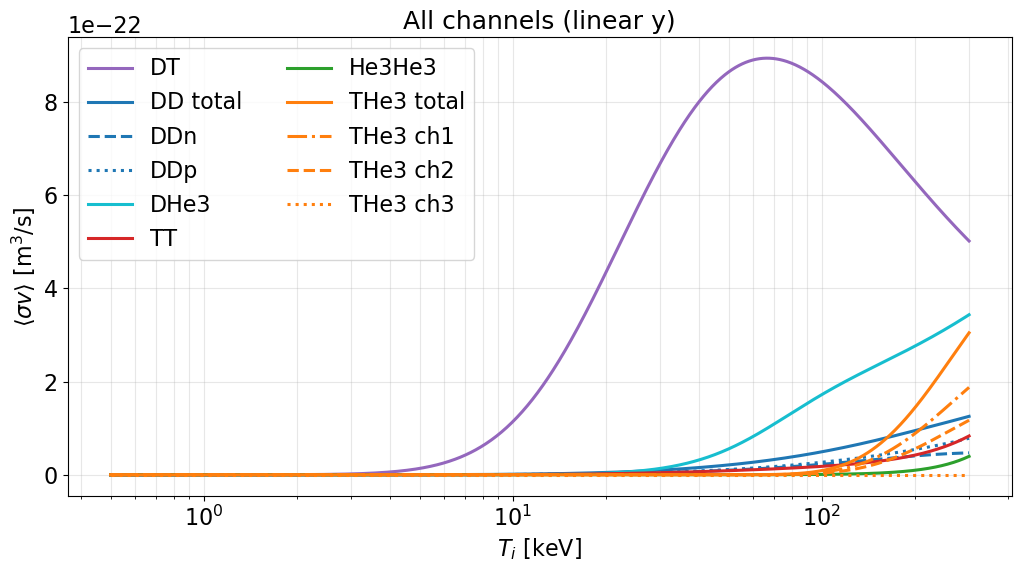

In [20]:
fig, ax = plt.subplots(figsize=(9, 8.5))

for name, values in reactivities.items():
    vals = np.asarray(values, dtype=float)
    vals_pos = np.where(vals > 0.0, vals, np.nan)
    if np.any(np.isfinite(vals_pos)):
        style = CHANNEL_STYLE[name]
        ax.plot(
            T_keV,
            vals_pos,
            lw=2.2,
            color=style['color'],
            linestyle=style['linestyle'],
            label=style['label'],
        )
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$T_i$ [keV]')
ax.set_ylabel(r'$\langle\sigma v\rangle$ [m$^3$/s]')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(1e-27, 5e-21)
ax.set_xlim(0.5, 300)
ax.legend(ncol=1)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 6.0))

for name, values in reactivities.items():
    style = CHANNEL_STYLE[name]
    ax.plot(
        T_keV,
        np.asarray(values, dtype=float),
        lw=2.2,
        color=style['color'],
        linestyle=style['linestyle'],
        label=style['label'],
    )
ax.set_xscale('log')
ax.set_xlabel('$T_i$ [keV]')
ax.set_ylabel(r'$\langle\sigma v\rangle$ [m$^3$/s]')
ax.set_title('All channels (linear y)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=2)

fig.tight_layout()
plt.show()


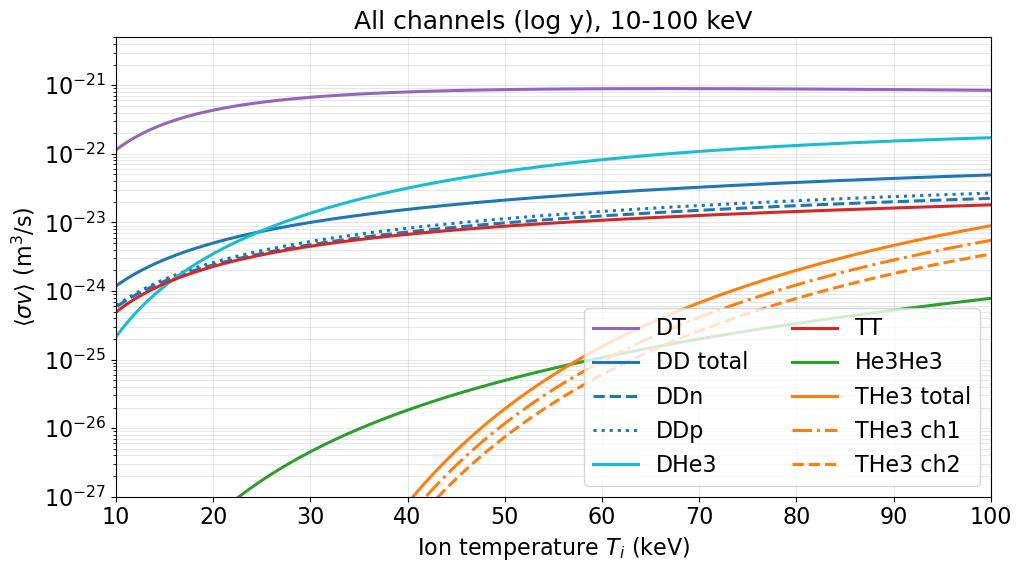

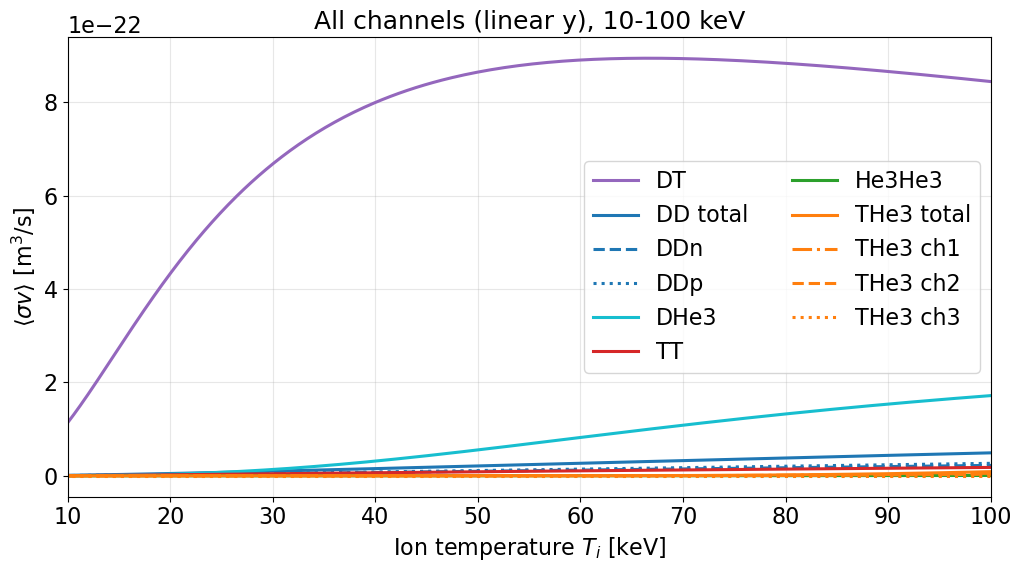

In [11]:
# Second plot: zoomed temperature range 10-100 keV
T_zoom_min_keV = 10.0
T_zoom_max_keV = 100.0

fig, ax = plt.subplots(figsize=(10.5, 6.0))

for name, values in reactivities.items():
    vals = np.asarray(values, dtype=float)
    vals_pos = np.where(vals > 0.0, vals, np.nan)
    if np.any(np.isfinite(vals_pos)):
        style = CHANNEL_STYLE[name]
        ax.plot(
            T_keV,
            vals_pos,
            lw=2.2,
            color=style['color'],
            linestyle=style['linestyle'],
            label=style['label'],
        )
ax.set_yscale('log')
ax.set_xlim(T_zoom_min_keV, T_zoom_max_keV)
ax.set_xlabel('Ion temperature $T_i$ (keV)')
ax.set_ylabel(r'$\langle\sigma v\rangle$ (m$^3$/s)')
ax.set_title('All channels (log y), 10-100 keV')
ax.set_ylim(1e-27, 5e-21)
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=2)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 6.0))

for name, values in reactivities.items():
    style = CHANNEL_STYLE[name]
    ax.plot(
        T_keV,
        np.asarray(values, dtype=float),
        lw=2.2,
        color=style['color'],
        linestyle=style['linestyle'],
        label=style['label'],
    )
ax.set_xlim(T_zoom_min_keV, T_zoom_max_keV)
ax.set_xlabel('Ion temperature $T_i$ [keV]')
ax.set_ylabel(r'$\langle\sigma v\rangle$ [m$^3$/s]')
ax.set_title('All channels (linear y), 10-100 keV')
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=2)

fig.tight_layout()
plt.show()
